In [15]:
! pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [10]:
data = pd.read_csv("C:/Users/marce/Documents/Proyectos data/data/train.csv")
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [11]:
data.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

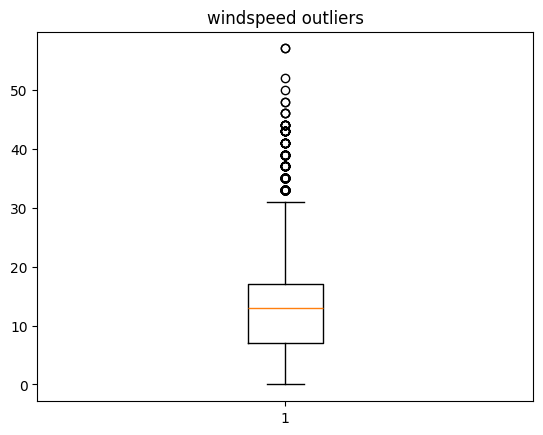

In [12]:
plt.boxplot(data['windspeed'])
plt.title("windspeed outliers")
plt.show()

In [13]:
data['windspeed'] = data['windspeed'].clip(upper=40)

In [14]:
data = data[data['temp'] >= 0]

In [15]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [16]:
data['hour']=data['datetime'].dt.hour
data['day_of_week']=data['datetime'].dt.dayofweek
data['month']=data['datetime'].dt.month

In [17]:
data['is_clear_weather'] = (data['weather'] == 1).astype(int)
data['is_rainy_weather'] = (data['weather'] >= 3).astype(int)

In [18]:
data['is_holiday_workingday'] = ((data['holiday'] == 1) & (data['workingday'] == 1)).astype(int)

In [19]:
data.drop(columns=["datetime"], inplace=True)


In [20]:
# Split the data into features and target
X = data.drop(columns=["count"])  # Features (all columns except 'count')
y = data["count"]  # Target variable
# Perform an 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Verify the split
print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (8708, 16)
Testing data size: (2178, 16)


2025/10/27 21:31:18 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2025/10/27 21:31:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

Model training complete. MAE: 3.6803246669967646, RMSE: 7.088694908391736


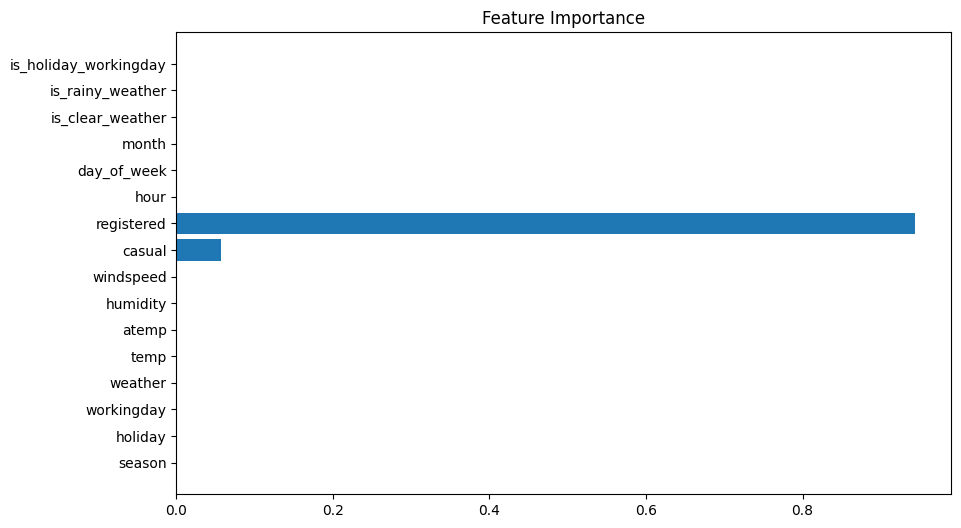

In [21]:
import mlflow
import mlflow.sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

model = DecisionTreeRegressor(max_depth=10, random_state=42)
with mlflow.start_run():
    # Log model parameters
    mlflow.log_param("model_type", "DecisionTreeRegressor")
    mlflow.log_param("max_depth", 10)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    
    # Log evaluation metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    
    # Plot and log feature importance as an artifact
    feature_importances = model.feature_importances_
    plt.figure(figsize=(10, 6))
    plt.barh(X_train.columns, feature_importances)
    plt.title("Feature Importance")
    plt.savefig("feature_importance.png")
    
    # Log the artifact (the feature importance plot)
    mlflow.log_artifact("feature_importance.png")
    
    # Log the model itself
    mlflow.sklearn.log_model(model, "model")
    
print(f"Model training complete. MAE: {mae}, RMSE: {rmse}")

In [23]:
mlflow.log_param("max_depth", 10)
mlflow.log_metric("MAE", mae) 
mlflow.log_metric("RMSE", rmse)
plt.savefig("feature_importance.png")
mlflow.log_artifact("feature_importance.png")
mlflow.sklearn.log_model(model, "model")


2025/10/27 21:32:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/27 21:32:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


<Figure size 640x480 with 0 Axes>

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
import mlflow
import mlflow.sklearn

model = DecisionTreeRegressor(random_state=42)
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 10, 20]
}
# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)
# Start an MLFlow run for hyperparameter tuning
with mlflow.start_run(nested=True):
    # Perform grid search
    grid_search.fit(X_train, y_train)
    
    # Log the best hyperparameters
    best_params = grid_search.best_params_
    mlflow.log_param("best_max_depth", best_params['max_depth'])
    mlflow.log_param("best_min_samples_split", best_params['min_samples_split'])
    
    # Log the best score (cross-validated)
    best_score = -grid_search.best_score_  # Convert to positive since we used neg_mean_squared_error
    mlflow.log_metric("best_cross_val_score", best_score)
    
    # Log the final model
    best_model = grid_search.best_estimator_
    mlflow.sklearn.log_model(best_model, "best_model")
    
    # Evaluate the model on the test set and log the result
    test_predictions = best_model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    mlflow.log_metric("test_RMSE", test_rmse)
    
print(f"Best Hyperparameters: {best_params}")
print(f"Test RMSE: {test_rmse}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits


2025/10/27 21:45:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/27 21:45:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Best Hyperparameters: {'max_depth': 15, 'min_samples_split': 10}
Test RMSE: 6.645717111734768


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import randint
# Define the hyperparameter distributions
param_distributions = {
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 20)
}
# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions, 
                                   n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42, verbose=1)
# Perform RandomizedSearchCV with MLFlow tracking
with mlflow.start_run(nested=True):
    random_search.fit(X_train, y_train)
    
    # Log the best hyperparameters and metrics
    best_params = random_search.best_params_
    mlflow.log_param("best_max_depth", best_params['max_depth'])
    mlflow.log_param("best_min_samples_split", best_params['min_samples_split'])
    
    best_score = -random_search.best_score_  # Convert to positive MSE
    mlflow.log_metric("best_cross_val_score", best_score)
    
    # Log the best model
    best_model = random_search.best_estimator_
    mlflow.sklearn.log_model(best_model, "best_model")
    
    # Evaluate and log test set performance
    test_predictions = best_model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    mlflow.log_metric("test_RMSE", test_rmse)
print(f"Best Hyperparameters: {best_params}")
print(f"Test RMSE: {test_rmse}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


2025/10/27 21:46:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/27 21:46:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Best Hyperparameters: {'max_depth': 15, 'min_samples_split': 5}
Test RMSE: 6.240402041286485


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mlflow
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [31]:
# Log the metrics using MLFlow
with mlflow.start_run(nested=True):
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)

In [32]:
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.999
RMSE: 6.240
MAE: 2.891


In [33]:
import mlflow
import mlflow.sklearn
with mlflow.start_run(nested=True):
    # Take the first row of the training dataset as the model input example.
    input_example = X_train.iloc[[0]]
    # The signature is automatically inferred from the input example and its predicted output.
    mlflow.sklearn.log_model(best_model, "bike_prediction_model", input_example=input_example)
    print("Model saved successfully!")

2025/10/27 21:51:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\marce\Documents\Proyectos data\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Model saved successfully!


In [36]:
import mlflow
import mlflow.sklearn

with mlflow.start_run(nested=True):
    mlflow.sklearn.log_model(model, "model")  # guarda modelo entrenado en artifacts/model


2025/10/27 23:12:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/27 23:13:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [ ]:
 mlflow models serve -m "runs:/0/models/m-1b1826f346e742e3a6a32e5398611a5e/artifacts" -p 1234 --no-conda